In [1]:
# --- 0. Setup and Imports ---
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Use notebook version of tqdm
import sys
import cv2

# Add project root to sys.path
notebook_path = os.path.abspath(os.getcwd())
project_root = os.path.dirname(notebook_path)
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added project root to sys.path: {project_root}")

%load_ext autoreload
%autoreload 2

# NuScenes imports
from nuscenes.nuscenes import NuScenes

# Project-specific imports
from src.core.m_detector import MDetector, OcclusionResult
from src.core.depth_image import DepthImage
from src.core.depth_image_library import DepthImageLibrary
from src.data_utils.nuscenes_helper import NuScenesProcessor, get_lidar_sweep_data
from src.visualization.video_helpers import create_visualization_frame # For BEV
from src.utils.visualization import mpl_fig_to_opencv_bgr # If using create_visualization_frame directly


Added project root to sys.path: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python


In [2]:
# Define the path to your configuration file
# Adjust this path if your notebook is in a different location relative to the config file
config_path = '../config/m_detector_config.yaml' 

# Load configuration
try:
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Configuration loaded successfully from: {config_path}")
except FileNotFoundError:
    print(f"ERROR: Configuration file not found at {config_path}")
    print("Please ensure the path is correct and the file exists.")
    config = None # Set config to None to prevent errors in subsequent cells if file not found

if config:
    # Print some key config values for verification
    print(f"  NuScenes dataroot: {config.get('nuscenes', {}).get('dataroot')}")
    print(f"  Map Consistency Enabled: {config.get('map_consistency_check', {}).get('enabled', False)}")
    print(f"  Num Historical DIs for Map Check: {config.get('map_consistency_check', {}).get('num_historical_di_for_map_check', 0)}")
    print(f"  Num Future DIs for Map Check: {config.get('map_consistency_check', {}).get('num_future_di_for_map_check', 0)}")
    print(f"  Depth Image Library Size: {config.get('depth_image', {}).get('library_size')}")
    
    # Ensure map consistency is enabled for this debugging session
    if not config.get('map_consistency_check', {}).get('enabled', False):
        print("\nWARNING: Map consistency is currently DISABLED in the config.")
        print("To debug map consistency, please enable it in 'm_detector_config.yaml'")
        # You could also override it here for the session if desired:
        # config['map_consistency_check']['enabled'] = True
        # print("Map consistency has been programmatically enabled for this session.")

Configuration loaded successfully from: ../config/m_detector_config.yaml
  NuScenes dataroot: /datasets/nuscenes
  Map Consistency Enabled: True
  Num Historical DIs for Map Check: 5
  Num Future DIs for Map Check: 5
  Depth Image Library Size: 20


In [3]:
if config:
    try:
        nusc = NuScenes(version=config['nuscenes']['version'], 
                        dataroot=config['nuscenes']['dataroot'], 
                        verbose=False) # Keep verbose False for cleaner notebook output
        print("NuScenes SDK initialized successfully.")
    except Exception as e:
        print(f"ERROR: Failed to initialize NuScenes SDK: {e}")
        print("Please check your NuScenes dataroot and version in the config file.")
        nusc = None

    if nusc:
        detector = MDetector(config)
        print("MDetector initialized successfully.")
else:
    print("Skipping NuScenes and MDetector initialization due to missing config.")
    nusc = None
    detector = None

NuScenes SDK initialized successfully.
[MDetector __init__] Parsed static_labels_for_map_check: ['non_event', <OcclusionResult.UNDETERMINED: 3>, 'STATIC_CONFIRMED_BY_MAP', 'pending_classification']
MDetector initialized successfully.


In [4]:
if nusc and detector:
    scene_index_to_debug = 0 # Choose a scene index (e.g., 0 for the first scene)
    
    # Define the segment of frames to load from the scene
    # These are indices within the scene's full list of LiDAR sweeps/tokens
    # For example, to load frames 40 through 49 (10 frames):
    slice_start_scene_index = 40 
    num_frames_in_slice = 10
    slice_end_scene_index = slice_start_scene_index + num_frames_in_slice # Exclusive end index for slicing

    try:
        selected_scene_info = nusc.scene[scene_index_to_debug]
        print(f"Selected scene: '{selected_scene_info['name']}' (Index: {scene_index_to_debug})")
    except IndexError:
        print(f"ERROR: Scene index {scene_index_to_debug} is out of range. Max index is {len(nusc.scene)-1}")
        selected_scene_info = None

    if selected_scene_info:
        processor = NuScenesProcessor(nusc)
        
        # Get all LiDAR tokens for the selected scene
        all_scene_tokens = processor.get_scene_tokens(scene_index_to_debug)
        print(f"Found {len(all_scene_tokens)} LiDAR tokens in the selected scene.")

        # Validate the requested slice
        if slice_start_scene_index >= len(all_scene_tokens):
            print(f"ERROR: slice_start_scene_index ({slice_start_scene_index}) is out of bounds "
                  f"for scene with {len(all_scene_tokens)} tokens.")
            tokens_for_slice = []
        elif slice_end_scene_index > len(all_scene_tokens):
            print(f"WARNING: slice_end_scene_index ({slice_end_scene_index}) exceeds available tokens. "
                  f"Adjusting to load until the end of the scene.")
            tokens_for_slice = all_scene_tokens[slice_start_scene_index:]
            num_frames_in_slice = len(tokens_for_slice) # Update actual number of frames
        else:
            tokens_for_slice = all_scene_tokens[slice_start_scene_index:slice_end_scene_index]
            num_frames_in_slice = len(tokens_for_slice) # Ensure this reflects actual slice size

        if not tokens_for_slice:
            print("No tokens selected for the slice. Cannot proceed with loading.")
        else:
            print(f"\nAttempting to load {num_frames_in_slice} LiDAR sweeps (from scene index "
                  f"{slice_start_scene_index} to {slice_start_scene_index + num_frames_in_slice - 1}) "
                  f"into MDetector's library...")
            
            # Clear the library before loading a new slice to ensure it only contains this segment
            # (if the library is smaller than the slice, deque handles it, but explicit clear is good for debug)
            if len(detector.depth_image_library._images) > 0:
                print(f"  Clearing existing {len(detector.depth_image_library._images)} DIs from library before loading new slice.")
                detector.depth_image_library.clear()
            
            loaded_di_tokens = [] # Stores tokens corresponding to DIs ACTUALLY in the library after loading

            for i, token in enumerate(tqdm(tokens_for_slice, desc="Loading slice")):
                try:
                    points, pose, timestamp = get_lidar_sweep_data(nusc, token)
                    
                    # Add sweep to detector. The DepthImageLibrary will handle its max_size.
                    # If num_frames_in_slice > library_size, older DIs from this slice will be pushed out.
                    di = detector.add_sweep_and_create_depth_image(points, pose, timestamp)
                    
                    # loaded_di_tokens should reflect what's *currently* in the library.
                    # Since DIs might be pushed out if slice > library_size, we rebuild it each time.
                    # However, for debugging, it's often easier if library_size >= num_frames_in_slice
                    # For now, let's assume library_size is large enough for the slice, or accept that
                    # loaded_di_tokens might not perfectly map to library indices if slice is very large.
                    # A simpler approach for `loaded_di_tokens` if library_size is an issue:
                    # loaded_di_tokens.append(token) 
                    # And then later, when picking center_di_token, ensure it's from a DI still in the library.
                    # For now, assuming library_size >= num_frames_in_slice for direct mapping.
                    # If not, `loaded_di_tokens` should be derived from `detector.depth_image_library._images` timestamps.

                except Exception as e:
                    print(f"ERROR processing token {token} (at slice index {i}): {e}")
                    break
            
            # After loading the slice, loaded_di_tokens should reflect the tokens of DIs *currently* in the library.
            # The library stores DIs in the order they were added (oldest to newest).
            # If the slice was larger than library.max_size, only the last `library.max_size` DIs from the slice are kept.
            loaded_di_tokens = [t for t in tokens_for_slice if any(di.timestamp == nusc.get('sample_data', t)['timestamp'] for di in detector.depth_image_library._images)]
            # This reconstruction of loaded_di_tokens can be slow. A better way:
            # Store the DI timestamps as they are added, then map back if needed.
            # For simplicity now, let's assume library_size >= num_frames_in_slice or adjust Cell 5 logic.

            # More robust way to get loaded_di_tokens if library might be smaller than slice:
            current_library_timestamps = [di.timestamp for di in detector.depth_image_library._images]
            temp_loaded_di_tokens = []
            # Iterate through the tokens we attempted to load (tokens_for_slice)
            # and see which ones actually made it into the library (by matching timestamps)
            # This assumes timestamps are unique enough for this mapping.
            token_to_ts_map = {nusc.get('sample_data', t)['timestamp']: t for t in tokens_for_slice}
            for lib_ts in current_library_timestamps:
                if lib_ts in token_to_ts_map:
                    temp_loaded_di_tokens.append(token_to_ts_map[lib_ts])
            loaded_di_tokens = temp_loaded_di_tokens
            
            print(f"\nFinished loading slice. DepthImageLibrary size: {len(detector.depth_image_library._images)}")
            if len(detector.depth_image_library._images) > 0:
                print(f"  Oldest DI in library (Timestamp: {detector.depth_image_library._images[0].timestamp/1e6:.2f}s)")
                print(f"  Newest DI in library (Timestamp: {detector.depth_image_library._images[-1].timestamp/1e6:.2f}s)")
                print(f"  Number of tokens successfully mapped to DIs in library: {len(loaded_di_tokens)}")

                # Important: If num_frames_in_slice > library_size, then loaded_di_tokens
                # will only contain the tokens for the DIs that remained in the library.
                # Cell 5 will need to select center_di_library_index based on the *actual* library size.
else:
    print("Skipping scene processing due to earlier errors.")

Selected scene: 'scene-0061' (Index: 0)
Found 382 LiDAR tokens in the selected scene.

Attempting to load 10 LiDAR sweeps (from scene index 40 to 49) into MDetector's library...


Loading slice:   0%|          | 0/10 [00:00<?, ?it/s]


Finished loading slice. DepthImageLibrary size: 10
  Oldest DI in library (Timestamp: 1532402929.65s)
  Newest DI in library (Timestamp: 1532402930.10s)
  Number of tokens successfully mapped to DIs in library: 10


In [5]:
if nusc and detector and len(detector.depth_image_library._images) >= 3: # Need at least 3 for past, center, future
    # Choose an index for the "center" DI from the library
    # Ensure this index is valid (e.g., not the very first or very last if you need past/future)
    # If num_initial_frames_to_load = 7, library indices are 0-6.
    # A good center_di_index could be 1, 2, 3, 4, or 5. Let's pick one in the middle.
    center_di_library_index = num_frames_in_slice // 2 
    if center_di_library_index == 0 and num_frames_in_slice > 1: # Avoid index 0 if we can have a past
        center_di_library_index = 1
    if center_di_library_index == len(detector.depth_image_library._images) -1 and num_frames_in_slice > 1: # Avoid last if we can have future
        center_di_library_index = len(detector.depth_image_library._images) -2
    
    if not (0 < center_di_library_index < len(detector.depth_image_library._images) - 1) and len(detector.depth_image_library._images) >=3 :
         print(f"Adjusting center_di_library_index to ensure past and future DIs can be selected.")
         if len(detector.depth_image_library._images) >=3:
             center_di_library_index = 1 # Default to 1 if library has at least 3 items.
         else:
             print("Not enough DIs in library for a full past-center-future setup. Need at least 3.")
             center_di = None # skip next steps


    center_di = detector.depth_image_library.get_image_by_index(center_di_library_index)
    center_di_token = loaded_di_tokens[center_di_library_index] # Token used to create this DI

    historical_di_for_occ = detector.depth_image_library.get_image_by_index(center_di_library_index - 1)
    future_di_for_occ = detector.depth_image_library.get_image_by_index(center_di_library_index + 1)

    print(f"Analyzing Center DI at library index: {center_di_library_index} (from token {center_di_token[-6:]})")
    print(f"  Center DI Timestamp: {center_di.timestamp/1e6:.2f}s, Points: {center_di.total_points_added}")
    if historical_di_for_occ:
        print(f"  Historical DI Timestamp: {historical_di_for_occ.timestamp/1e6:.2f}s, Points: {historical_di_for_occ.total_points_added}")
    else:
        print("  No valid historical DI for occlusion check.")
    if future_di_for_occ:
        print(f"  Future DI Timestamp: {future_di_for_occ.timestamp/1e6:.2f}s, Points: {future_di_for_occ.total_points_added}")
    else:
        print("  No valid future DI for occlusion check.")

    # --- Select a specific point from center_di to analyze ---
    point_to_check_global = None
    center_timestamp_for_check = None
    original_point_info_in_center_di = None

    if center_di.total_points_added > 0:
        # Option 1: Get all points and pick one (e.g., the 10th point)
        # all_points_data = center_di.get_all_points(with_labels=True) # with_labels might not be set yet
        # if all_points_data['all'].shape[0] > 0:
        #     point_idx_to_select = min(10, all_points_data['all'].shape[0] - 1)
        #     point_to_check_global = all_points_data['all'][point_idx_to_select]
        #     # Finding original_pt_info for this is harder.

        # Option 2: Iterate pixel_points (as in your plan)
        found_point = False
        for (v_idx, h_idx), points_list_in_pixel in center_di.pixel_points.items():
            if points_list_in_pixel:
                # For simplicity, pick the first point from the first non-empty pixel
                # In a real debug session, you might look for a point on a known object
                original_point_info_in_center_di = points_list_in_pixel[0]
                point_to_check_global = original_point_info_in_center_di['global_pt']
                center_timestamp_for_check = center_di.timestamp # Timestamp of the DI the point belongs to
                print(f"\nSelected point for analysis from center_di (pixel {v_idx},{h_idx}):")
                print(f"  Global Coords: {point_to_check_global}")
                print(f"  Original Label in DI (if any): {original_point_info_in_center_di.get('label')}")
                found_point = True
                break
        if not found_point:
            print("No points found within the center_di's pixel_points to select for analysis.")
    else:
        print(f"Center DI (Index {center_di_library_index}) has no points.")
        
else:
    print("Skipping point selection due to earlier errors or insufficient DIs in library.")
    center_di = None # Ensure it's None if not set

Analyzing Center DI at library index: 5 (from token 794dfd)
  Center DI Timestamp: 1532402929.90s, Points: 25211
  Historical DI Timestamp: 1532402929.85s, Points: 25154
  Future DI Timestamp: 1532402929.95s, Points: 25201

Selected point for analysis from center_di (pixel 0,16):
  Global Coords: [ 4.07869943e+02  1.16133845e+03 -5.97475022e-02]
  Original Label in DI (if any): pending_classification



Generating Bird's-Eye View (BEV) of the Center DI with the target point...


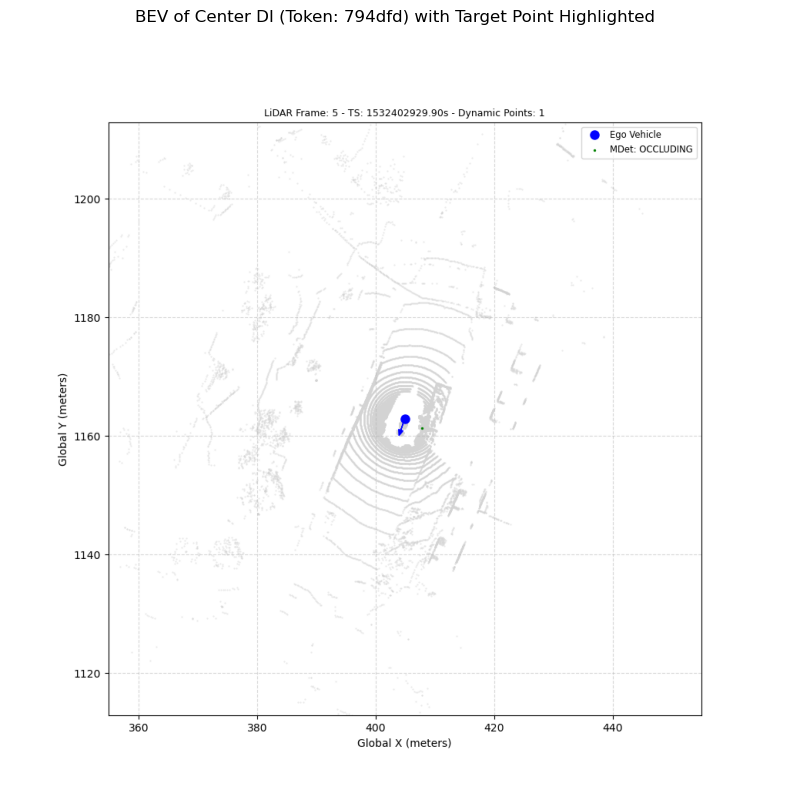

In [6]:
if center_di and point_to_check_global is not None:
    print("\nGenerating Bird's-Eye View (BEV) of the Center DI with the target point...")

    # Prepare points for create_visualization_frame
    # We want to highlight our point_to_check_global. Let's plot it as 'dynamic' (green).
    points_for_bev = {
        'dynamic': np.array([point_to_check_global]), # Our target point
        'occluded': np.empty((0, 3)),          # No other specific occluded points for this viz
        'undetermined': np.empty((0, 3))       # No other specific undetermined points
    }
    
    # To plot all other points from center_di as grey background (like original lidar sweep)
    # we can pass them as 'all_lidar_points' if we modify create_visualization_frame,
    # or rely on its internal mechanism if nusc and lidar_token are correctly set.

    # The create_visualization_frame function expects a frame_index, width, height, config, nusc, lidar_token.
    # Width and height for the plot figure, not necessarily video.
    bev_fig_width = config.get('video_generation', {}).get('bev_fig_width_inches', 10)
    bev_fig_height = config.get('video_generation', {}).get('bev_fig_height_inches', 10)

    # Get the original LiDAR points for the center_di's sweep to plot as background
    # This is what create_visualization_frame does internally if lidar_token is provided.
    # We can also fetch them here and pass them if we adapt create_visualization_frame
    # or if we want more control.
    # For now, let's rely on create_visualization_frame's existing logic using the center_di_token.

    try:
        # Using center_di_library_index as frame_index for title and legend logic
        # The lidar_token should be the one corresponding to center_di
        bev_frame_bgr = create_visualization_frame(
            depth_image=center_di,  # Pass the center_di itself
            points=points_for_bev,
            frame_index=center_di_library_index, # For title and legend logic
            width=1280, # Default, can be adjusted
            height=720, # Default, can be adjusted
            config=config,
            nusc=nusc,
            lidar_token=center_di_token # Token corresponding to the center_di
        )

        # Convert BGR (OpenCV) to RGB (Matplotlib)
        bev_frame_rgb = cv2.cvtColor(bev_frame_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(bev_fig_width, bev_fig_height))
        plt.imshow(bev_frame_rgb)
        plt.title(f"BEV of Center DI (Token: {center_di_token[-6:]}) with Target Point Highlighted")
        plt.axis('off') # Hide axes for a cleaner image plot
        plt.show()
        
    except Exception as e:
        print(f"ERROR generating BEV visualization: {e}")
        import traceback
        traceback.print_exc()

else:
    print("Skipping BEV visualization as center_di or point_to_check_global is not available.")

In [7]:
# Cell 7: Perform and Analyze Past Map Consistency Check

if detector and point_to_check_global is not None and center_timestamp_for_check is not None:
    print(f"--- Analyzing Map Consistency (Past) for point: {point_to_check_global} ---")
    
    is_consistent_past, debug_info_past = detector.is_map_consistent(
        point_to_check_global, 
        center_timestamp_for_check, 
        check_direction='past', 
        return_debug_info=True
    )
    
    print(f"\nOverall 'is_consistent_past': {is_consistent_past}")
    
    if debug_info_past:
        print(f"  Consistent Count: {debug_info_past['consistent_count']}")
        print(f"  Total DIs Checked Against: {debug_info_past['total_checks_attempted_on_dis']}")
        if 'reason' in debug_info_past:
            print(f"  Reason for result (if applicable): {debug_info_past['reason']}")

        print("\n  Configuration used for this check:")
        for cfg_key, cfg_val in debug_info_past.get('config_params', {}).items():
            print(f"    {cfg_key}: {cfg_val}")
            
        print("\n  Details per Reference DI (Past):")
        for i, di_details in enumerate(debug_info_past['relevant_dis_details']):
            print(f"  ------------------------------------")
            print(f"  Reference DI #{i+1} (Timestamp: {di_details['di_timestamp']/1e6:.2f}s)")
            print(f"    Target Projection Successful: {di_details['projection_successful']}")
            if di_details['projection_successful']:
                print(f"      Target Projected Sph Coords (phi,theta,d): {np.rad2deg(di_details['projected_sph_coords_of_target'][0]):.2f}°, "
                      f"{np.rad2deg(di_details['projected_sph_coords_of_target'][1]):.2f}°, "
                      f"{di_details['projected_sph_coords_of_target'][2]:.2f}m")
                print(f"      Target Projected Pixel (v,h): {di_details['projected_pixel_indices_of_target']}")
            print(f"    Pixel Content Found in Ref DI: {di_details['pixel_content_found']}")
            print(f"    Match Found in this Ref DI: {di_details['match_found_in_this_di']}")
            
            if di_details['checked_static_points_in_di']:
                print(f"    Checked {len(di_details['checked_static_points_in_di'])} static points in this DI's pixel region:")
                for j, static_pt_info in enumerate(di_details['checked_static_points_in_di']):
                    print(f"      Static Pt #{j+1}: Label='{static_pt_info['label']}', Global Z={static_pt_info['static_pt_global'][2]:.2f}m")
                    if 'reason_skipped' in static_pt_info:
                        print(f"        Skipped: {static_pt_info['reason_skipped']}")
                        continue
                    print(f"        Proj Sph Coords (phi,th,d): {np.rad2deg(static_pt_info['static_pt_sph_coords_in_di'][0]):.2f}°, "
                          f"{np.rad2deg(static_pt_info['static_pt_sph_coords_in_di'][1]):.2f}°, "
                          f"{static_pt_info['static_pt_sph_coords_in_di'][2]:.2f}m")
                    print(f"        Phi Diff: {np.rad2deg(static_pt_info['phi_diff']):.2f}° (Consistent: {static_pt_info['phi_consistent']}) "
                          f"| Theta Diff: {np.rad2deg(static_pt_info['theta_diff']):.2f}° (Consistent: {static_pt_info['theta_consistent']})")
                    print(f"        Depth Target: {static_pt_info['depth_target']:.2f}m, Depth Static: {static_pt_info['depth_static_in_di']:.2f}m "
                          f"(Consistent: {static_pt_info['depth_consistent']})")
                    print(f"        --> Match for this static point: {static_pt_info['is_match']}")
            else:
                if di_details['pixel_content_found']: # Pixel had content, but no static points were eligible/checked
                     print(f"    No eligible static points checked in this DI's pixel region.")

            # TODO: Add visualization call here for each reference DI if desired
            # e.g., plot_map_consistency_debug_bev(point_to_check_global, di, di_details)
            
    else:
        print("Debug info for 'past' check not available.")
        
else:
    print("Skipping Past Map Consistency Check as prerequisites are not met.")

--- Analyzing Map Consistency (Past) for point: [ 4.07869943e+02  1.16133845e+03 -5.97475022e-02] ---

Overall 'is_consistent_past': True
  Consistent Count: 3
  Total DIs Checked Against: 3

  Configuration used for this check:
    num_historical_di_for_map_check: 5
    num_future_di_for_map_check: 5
    epsilon_phi_map_rad: 0.017453292519943295
    epsilon_theta_map_rad: 0.017453292519943295
    epsilon_depth_forward_map: 0.3
    epsilon_depth_backward_map: 0.3
    static_labels_for_map_check: ['non_event', 'OcclusionResult.UNDETERMINED', 'STATIC_CONFIRMED_BY_MAP', 'pending_classification']
    consistency_threshold: 0.5

  Details per Reference DI (Past):
  ------------------------------------
  Reference DI #1 (Timestamp: 1532402929.85s)
    Target Projection Successful: True
      Target Projected Sph Coords (phi,theta,d): 179.83°, -29.37°, 3.77m
      Target Projected Pixel (v,h): [0, 899]
    Pixel Content Found in Ref DI: True
    Match Found in this Ref DI: True
    Checked 1 

In [8]:
# Cell 8: Perform and Analyze Future Map Consistency Check
if detector and point_to_check_global is not None and center_timestamp_for_check is not None:
    print(f"\n--- Analyzing Map Consistency (Future) for point: {point_to_check_global} ---")
    
    is_consistent_future, debug_info_future = detector.is_map_consistent(
        point_to_check_global, 
        center_timestamp_for_check, 
        check_direction='future', 
        return_debug_info=True
    )
    
    print(f"\nOverall 'is_consistent_future': {is_consistent_future}")
    
    if debug_info_future:
        print(f"  Consistent Count: {debug_info_future['consistent_count']}")
        print(f"  Total DIs Checked Against: {debug_info_future['total_checks_attempted_on_dis']}")
        if 'reason' in debug_info_future:
            print(f"  Reason for result (if applicable): {debug_info_future['reason']}")

        print("\n  Configuration used for this check:")
        for cfg_key, cfg_val in debug_info_future.get('config_params', {}).items():
            print(f"    {cfg_key}: {cfg_val}")
            
        print("\n  Details per Reference DI (Future):")
        for i, di_details in enumerate(debug_info_future['relevant_dis_details']):
            print(f"  ------------------------------------")
            print(f"  Reference DI #{i+1} (Timestamp: {di_details['di_timestamp']/1e6:.2f}s)")
            print(f"    Target Projection Successful: {di_details['projection_successful']}")
            if di_details['projection_successful']:
                print(f"      Target Projected Sph Coords (phi,theta,d): {np.rad2deg(di_details['projected_sph_coords_of_target'][0]):.2f}°, "
                      f"{np.rad2deg(di_details['projected_sph_coords_of_target'][1]):.2f}°, "
                      f"{di_details['projected_sph_coords_of_target'][2]:.2f}m")
                print(f"      Target Projected Pixel (v,h): {di_details['projected_pixel_indices_of_target']}")
            print(f"    Pixel Content Found in Ref DI: {di_details['pixel_content_found']}")
            print(f"    Match Found in this Ref DI: {di_details['match_found_in_this_di']}")
            
            if di_details['checked_static_points_in_di']:
                print(f"    Checked {len(di_details['checked_static_points_in_di'])} static points in this DI's pixel region:")
                for j, static_pt_info in enumerate(di_details['checked_static_points_in_di']):
                    print(f"      Static Pt #{j+1}: Label='{static_pt_info['label']}', Global Z={static_pt_info['static_pt_global'][2]:.2f}m")
                    if 'reason_skipped' in static_pt_info:
                        print(f"        Skipped: {static_pt_info['reason_skipped']}")
                        continue
                    print(f"        Proj Sph Coords (phi,th,d): {np.rad2deg(static_pt_info['static_pt_sph_coords_in_di'][0]):.2f}°, "
                          f"{np.rad2deg(static_pt_info['static_pt_sph_coords_in_di'][1]):.2f}°, "
                          f"{static_pt_info['static_pt_sph_coords_in_di'][2]:.2f}m")
                    print(f"        Phi Diff: {np.rad2deg(static_pt_info['phi_diff']):.2f}° (Consistent: {static_pt_info['phi_consistent']}) "
                          f"| Theta Diff: {np.rad2deg(static_pt_info['theta_diff']):.2f}° (Consistent: {static_pt_info['theta_consistent']})")
                    print(f"        Depth Target: {static_pt_info['depth_target']:.2f}m, Depth Static: {static_pt_info['depth_static_in_di']:.2f}m "
                          f"(Consistent: {static_pt_info['depth_consistent']})")
                    print(f"        --> Match for this static point: {static_pt_info['is_match']}")
            else:
                if di_details['pixel_content_found']: # Pixel had content, but no static points were eligible/checked
                     print(f"    No eligible static points checked in this DI's pixel region.")

            # TODO: Add visualization call here for each reference DI if desired
            # e.g., plot_map_consistency_debug_bev(point_to_check_global, di, di_details)
    else:
        print("Debug info for 'future' check not available.")
        
else:
    print("Skipping Future Map Consistency Check as prerequisites are not met.")


--- Analyzing Map Consistency (Future) for point: [ 4.07869943e+02  1.16133845e+03 -5.97475022e-02] ---

Overall 'is_consistent_future': True
  Consistent Count: 2
  Total DIs Checked Against: 4

  Configuration used for this check:
    num_historical_di_for_map_check: 5
    num_future_di_for_map_check: 5
    epsilon_phi_map_rad: 0.017453292519943295
    epsilon_theta_map_rad: 0.017453292519943295
    epsilon_depth_forward_map: 0.3
    epsilon_depth_backward_map: 0.3
    static_labels_for_map_check: ['non_event', 'OcclusionResult.UNDETERMINED', 'STATIC_CONFIRMED_BY_MAP', 'pending_classification']
    consistency_threshold: 0.5

  Details per Reference DI (Future):
  ------------------------------------
  Reference DI #1 (Timestamp: 1532402929.95s)
    Target Projection Successful: True
      Target Projected Sph Coords (phi,theta,d): -166.91°, -29.00°, 3.87m
      Target Projected Pixel (v,h): [1, 32]
    Pixel Content Found in Ref DI: True
    Match Found in this Ref DI: False
    Ch

In [9]:
# Cell 10: Test Setup for _determine_final_label_bidirectional_simplified

from src.core.constants import OcclusionResult # Ensure this path is correct

# This is the point we've been tracking
# point_to_check_global = ... (should be defined from earlier cells)
# center_di_timestamp = ... (should be defined from earlier cells)

# Results from previous map consistency checks for point_to_check_global:
# is_consistent_past = True  (from Cell 7 output)
# is_consistent_future = False (from Cell 8 output)

# To make this cell self-contained for testing the labeling logic,
# we'll define various scenarios.

# --- Define Test Cases ---
# Each test case is a dictionary:
# {
#   "description": "Human-readable description of the scenario",
#   "evidence": {
#       'past_raw_occ': OcclusionResult.SOME_VALUE,
#       'future_raw_occ': OcclusionResult.SOME_VALUE,
#       'is_map_consistent_past': True/False,
#       'is_map_consistent_future': True/False
#   },
#   "expected_label": OcclusionResult.EXPECTED_OUTCOME (based on your YAML config)
# }

# Helper to quickly get OcclusionResult from string for expected_label, if easier to write
def label_str_to_enum(label_str):
    if label_str.upper() == "DYNAMIC": return OcclusionResult.OCCLUDING_IMAGE
    if label_str.upper() == "STATIC": return OcclusionResult.OCCLUDED_BY_IMAGE
    if label_str.upper() == "EMPTY": return OcclusionResult.EMPTY_IN_IMAGE
    if label_str.upper() == "UNDETERMINED": return OcclusionResult.UNDETERMINED
    raise ValueError(f"Unknown label string: {label_str}")

test_cases = [
    # Scenario 1: Strong Static - Both Map Consistencies are True (should trigger override)
    {
        "description": "Override: Both MC True -> STATIC",
        "evidence": {
            'past_raw_occ': OcclusionResult.OCCLUDING_IMAGE, # Raw occlusion is dynamic
            'future_raw_occ': OcclusionResult.OCCLUDING_IMAGE, # Raw occlusion is dynamic
            'is_map_consistent_past': True,
            'is_map_consistent_future': True
        },
        # Expected: Depends on `both_map_consistent_override` in config.
        # If "STATIC", then OcclusionResult.OCCLUDED_BY_IMAGE
        "expected_label": OcclusionResult.OCCLUDED_BY_IMAGE # Assuming config: both_map_consistent_override: "STATIC"
    },

    # Scenario 2: Past Dynamic (OCCLUDING, MC False), Future Static (OCCLUDING, MC True)
    # EPS = DYNAMIC
    # EFS = STATIC (assuming future_dynamic_mc_true_outcome: "STATIC")
    {
        "description": "Past Dynamic (MC False), Future Static (MC True)",
        "evidence": {
            'past_raw_occ': OcclusionResult.OCCLUDING_IMAGE,
            'future_raw_occ': OcclusionResult.OCCLUDING_IMAGE, # Future raw suggests dynamic
            'is_map_consistent_past': False, # Past is truly dynamic
            'is_map_consistent_future': True   # Future dynamic signal overridden by MC
        },
        # Expected: Depends on `past_dynamic_future_static_outcome`
        # If "DYNAMIC", then OcclusionResult.OCCLUDING_IMAGE
        "expected_label": OcclusionResult.OCCLUDING_IMAGE # Assuming config: past_dynamic_future_static_outcome: "DYNAMIC"
    },
    
    # Scenario 3: Past Static (OCCLUDED), Future Dynamic (OCCLUDING, MC False)
    # EPS = STATIC
    # EFS = DYNAMIC
    {
        "description": "Past Static, Future Dynamic (MC False)",
        "evidence": {
            'past_raw_occ': OcclusionResult.OCCLUDED_BY_IMAGE,
            'future_raw_occ': OcclusionResult.OCCLUDING_IMAGE,
            'is_map_consistent_past': False, # MC doesn't matter as much if past_raw_occ is OCCLUDED
            'is_map_consistent_future': False
        },
        # Expected: Depends on `past_static_future_dynamic_outcome`
        # If "DYNAMIC", then OcclusionResult.OCCLUDING_IMAGE
        "expected_label": OcclusionResult.OCCLUDING_IMAGE # Assuming config: past_static_future_dynamic_outcome: "DYNAMIC"
    },

    # Scenario 4: Both raw occlusions are UNDETERMINED, both MC are False
    # EPS = UNDETERMINED
    # EFS = UNDETERMINED
    {
        "description": "All Undetermined/False",
        "evidence": {
            'past_raw_occ': OcclusionResult.UNDETERMINED,
            'future_raw_occ': OcclusionResult.UNDETERMINED,
            'is_map_consistent_past': False,
            'is_map_consistent_future': False
        },
        # Expected: Depends on `default_ambiguous_outcome`
        # If "UNDETERMINED", then OcclusionResult.UNDETERMINED
        "expected_label": OcclusionResult.UNDETERMINED # Assuming config: default_ambiguous_outcome: "UNDETERMINED"
    },

    # Scenario 5: Your specific point_to_check_global's map consistency results
    # We need placeholder/assumed raw occlusion results for this point.
    # Let's assume after raw occlusion checks, point_to_check_global was:
    # past_raw_occ = OcclusionResult.UNDETERMINED (e.g. no clear occlusion with DI-1)
    # future_raw_occ = OcclusionResult.UNDETERMINED (e.g. no clear occlusion with DI+1)
    {
        "description": "Point Under Test: MC_Past=T, MC_Future=F, RawOccs=UNDET",
        "evidence": {
            'past_raw_occ': OcclusionResult.UNDETERMINED, # ASSUMPTION for point_to_check_global
            'future_raw_occ': OcclusionResult.UNDETERMINED, # ASSUMPTION for point_to_check_global
            'is_map_consistent_past': True,  # From your Cell 7 output
            'is_map_consistent_future': False # From your Cell 8 output
        },
        # Logic:
        # EPS: past_raw_occ=UNDET. is_mc_past=True. This combination isn't explicitly handled by
        #      `past_occluding_mc_true_outcome`. It falls to effective_past_state_str = "UNDETERMINED".
        #      (Correction: My refactored `_determine_final_label` would make EPS="UNDETERMINED" here.
        #       If past_raw_occ is UNDETERMINED, is_mc_past doesn't change it from UNDETERMINED in that logic)
        # EFS: future_raw_occ=UNDET. is_mc_future=False. EFS="UNDETERMINED".
        # Expected: EPS=UNDETERMINED, EFS=UNDETERMINED -> default_ambiguous_outcome
        "expected_label": OcclusionResult.UNDETERMINED # Assuming config: default_ambiguous_outcome: "UNDETERMINED"
    },
    
    # Scenario 6: Past OCCLUDING but MC_Past is True (EPS becomes STATIC)
    #             Future OCCLUDING but MC_Future is False (EFS becomes DYNAMIC)
    {
        "description": "Past Occluding (MC True -> EPS=STATIC), Future Occluding (MC False -> EFS=DYNAMIC)",
        "evidence": {
            'past_raw_occ': OcclusionResult.OCCLUDING_IMAGE,
            'future_raw_occ': OcclusionResult.OCCLUDING_IMAGE,
            'is_map_consistent_past': True,
            'is_map_consistent_future': False
        },
        # EPS = STATIC (if past_occluding_mc_true_outcome: "STATIC")
        # EFS = DYNAMIC
        # Expected: past_static_future_dynamic_outcome
        "expected_label": OcclusionResult.OCCLUDING_IMAGE # Assuming past_occluding_mc_true_outcome: "STATIC"
                                                        # and past_static_future_dynamic_outcome: "DYNAMIC"
    }
    # Add more test cases to cover:
    # - Different raw occlusion types (EMPTY_IN_IMAGE for past)
    # - All combinations of True/False for map consistency flags
    # - Scenarios that test each of your new YAML configuration rules.
]

print(f"Defined {len(test_cases)} test cases for final labeling logic.")
if 'detector' not in locals() or detector is None:
    print("WARNING: MDetector 'detector' instance not found. Please ensure it's initialized with the new config.")
else:
    # Quick check of a config value to see if it's loaded
    print(f"  Config check: both_map_consistent_override = {detector.config.get('temporal_processing', {}).get('both_map_consistent_override', 'NOT_FOUND')}")

Defined 6 test cases for final labeling logic.
  Config check: both_map_consistent_override = STATIC


In [10]:
# Cell 11: Execute Final Labeling Logic Tests

if 'detector' not in locals() or detector is None:
    print("ERROR: MDetector 'detector' instance not found. Cannot run tests.")
    print("Please ensure 'detector' is initialized correctly in a previous cell with the new YAML configuration.")
elif not test_cases:
    print("No test cases defined in Cell 10.")
else:
    print("\n--- Running Final Labeling Logic Tests ---")
    passed_count = 0
    failed_count = 0

    for i, tc in enumerate(test_cases):
        print(f"\nTest Case #{i+1}: {tc['description']}")
        
        evidence = tc['evidence']
        expected_label = tc['expected_label']
        
        print(f"  Inputs (Evidence):")
        for k, v_item in evidence.items(): # Renamed v to v_item to avoid conflict
            print(f"    {k}: {v_item}")
        print(f"  Expected Label: {expected_label.name if isinstance(expected_label, OcclusionResult) else expected_label}")

        try:
            actual_label = detector._determine_final_label_bidirectional_simplified(evidence)
            print(f"  Actual Label:   {actual_label.name if isinstance(actual_label, OcclusionResult) else actual_label}")

            if actual_label == expected_label:
                print("  Result: PASSED")
                passed_count += 1
            else:
                print(f"  Result: FAILED <----*********")
                failed_count += 1
        except Exception as e:
            print(f"  ERROR during test execution: {e}")
            failed_count += 1
            import traceback
            traceback.print_exc()


    print("\n--- Test Summary ---")
    print(f"Total Tests: {len(test_cases)}")
    print(f"Passed: {passed_count}")
    print(f"Failed: {failed_count}")

    if failed_count == 0:
        print("All tests passed successfully!")
    else:
        print("Some tests failed. Please review the output and your configuration/logic.")


--- Running Final Labeling Logic Tests ---

Test Case #1: Override: Both MC True -> STATIC
  Inputs (Evidence):
    past_raw_occ: OcclusionResult.OCCLUDING_IMAGE
    future_raw_occ: OcclusionResult.OCCLUDING_IMAGE
    is_map_consistent_past: True
    is_map_consistent_future: True
  Expected Label: OCCLUDED_BY_IMAGE
  Actual Label:   OCCLUDED_BY_IMAGE
  Result: PASSED

Test Case #2: Past Dynamic (MC False), Future Static (MC True)
  Inputs (Evidence):
    past_raw_occ: OcclusionResult.OCCLUDING_IMAGE
    future_raw_occ: OcclusionResult.OCCLUDING_IMAGE
    is_map_consistent_past: False
    is_map_consistent_future: True
  Expected Label: OCCLUDING_IMAGE
  Actual Label:   OCCLUDING_IMAGE
  Result: PASSED

Test Case #3: Past Static, Future Dynamic (MC False)
  Inputs (Evidence):
    past_raw_occ: OcclusionResult.OCCLUDED_BY_IMAGE
    future_raw_occ: OcclusionResult.OCCLUDING_IMAGE
    is_map_consistent_past: False
    is_map_consistent_future: False
  Expected Label: OCCLUDING_IMAGE
  Ac

In [11]:
# Cell 12: Setup for Full Sweep Processing Test

import matplotlib.pyplot as plt
import numpy as np
# from src.core.constants import OcclusionResult # Already imported

# Ensure detector is initialized and DIs are loaded
if 'detector' not in locals() or detector is None:
    print("ERROR: MDetector 'detector' instance not found. Please initialize it and load DIs.")
elif not detector.depth_image_library or len(detector.depth_image_library._images) < 3:
    print("ERROR: Depth image library does not have enough images for a bidirectional check (need at least 3).")
else:
    # Choose a center_index. For example, the middle DI if many are loaded,
    # or a specific one like index 2 if you have at least 3 DIs (0, 1, 2, 3, ...)
    # Ensure center_index allows for center_index-1 and center_index+1
    num_dis = len(detector.depth_image_library._images)
    if num_dis >= 3:
        center_index_to_process = 1 # A common choice for testing (0 is past, 1 is center, 2 is future)
        # Or, if you used a specific DI for point_to_check_global earlier,
        # and that DI's index is known and suitable:
        # center_index_to_process = index_of_di_containing_point_to_check_global
        
        # Make sure the chosen index is valid
        if not (0 < center_index_to_process < num_dis -1):
             center_index_to_process = num_dis // 2 # Fallback to middle if initial choice is bad
        if not (0 < center_index_to_process < num_dis -1) and num_dis >=3 : # If still bad, pick first possible
             center_index_to_process = 1


        print(f"Selected center_index_to_process: {center_index_to_process}")
        center_di_to_process = detector.depth_image_library._images[center_index_to_process]
        print(f"Timestamp of center_di_to_process: {center_di_to_process.timestamp / 1e6}s")

        # Verify map consistency is enabled in config if you want to test its interaction
        map_consistency_config = detector.config.get('map_consistency_check', {})
        map_consistency_enabled_runtime = map_consistency_config.get('enabled', False)
        detector.map_consistency_enabled = map_consistency_enabled_runtime # Ensure runtime flag matches config
        
        print(f"Map Consistency Enabled (runtime): {detector.map_consistency_enabled}")
        if detector.map_consistency_enabled:
            print(f"  Static labels for map check: {map_consistency_config.get('static_labels_for_map_check')}")
            print(f"  Num historical for map check: {map_consistency_config.get('num_historical_di_for_map_check')}")

        print("\nRelevant Final Labeling Config (from detector.config['temporal_processing']):")
        final_label_cfg = detector.config.get('temporal_processing', {})
        print(f"  both_map_consistent_override: {final_label_cfg.get('both_map_consistent_override', 'NOT_FOUND')}")
        print(f"  past_occluding_mc_true_outcome: {final_label_cfg.get('past_occluding_mc_true_outcome', 'NOT_FOUND')}")
        print(f"  future_dynamic_mc_true_outcome: {final_label_cfg.get('future_dynamic_mc_true_outcome', 'NOT_FOUND')}")
        print(f"  past_dynamic_future_static_outcome: {final_label_cfg.get('past_dynamic_future_static_outcome', 'NOT_FOUND')}")
        # Add more config printouts if desired

        # IMPORTANT: Reset labels in center_di_to_process to 'pending_classification' or 'non_event'
        # This simulates the state before process_and_label_di_bidirectional is called.
        # The method process_and_label_di_bidirectional expects points to have their initial labels.
        initial_label_for_reset = "non_event" if not detector.is_ready_for_processing() else "pending_classification"
        print(f"Resetting labels in DI {center_index_to_process} to '{initial_label_for_reset}' before processing.")
        points_reset_count = 0
        for v_idx_reset in range(center_di_to_process.num_pixels_v):
            for h_idx_reset in range(center_di_to_process.num_pixels_h):
                pixel_content_reset = center_di_to_process.get_pixel_info(v_idx_reset, h_idx_reset)
                if pixel_content_reset and pixel_content_reset['points']:
                    for pt_info_reset in pixel_content_reset['points']:
                        pt_info_reset['label'] = initial_label_for_reset
                        points_reset_count +=1
        print(f"Reset {points_reset_count} points in DI {center_index_to_process}.")

    else:
        print("Not enough DIs loaded to select a suitable center_index.")
        center_index_to_process = None

Selected center_index_to_process: 1
Timestamp of center_di_to_process: 1532402929.697797s
Map Consistency Enabled (runtime): True
  Static labels for map check: ['NON_EVENT', 'UNDETERMINED', 'STATIC_CONFIRMED_BY_MAP', 'PENDING_CLASSIFICATION']
  Num historical for map check: 5

Relevant Final Labeling Config (from detector.config['temporal_processing']):
  both_map_consistent_override: STATIC
  past_occluding_mc_true_outcome: STATIC
  future_dynamic_mc_true_outcome: STATIC
  past_dynamic_future_static_outcome: DYNAMIC
Resetting labels in DI 1 to 'pending_classification' before processing.
Reset 25149 points in DI 1.


In [12]:
# Cell 13: Run process_and_label_di_bidirectional for the selected DI

if 'center_index_to_process' in locals() and center_index_to_process is not None and detector:
    print(f"\n--- Processing DI at index: {center_index_to_process} ---")
    
    # Ensure the detector's internal state for readiness is based on the current library size
    # This might affect initial labeling if process_and_label_di_bidirectional re-checks it.
    # However, we reset labels manually above.
    
    processing_stats = detector.process_and_label_di_bidirectional(center_index_to_process)
    
    print("\nProcessing Statistics:")
    for key, value in processing_stats.items():
        if key == 'label_counts':
            print(f"  {key}:")
            for label, count in value.items():
                print(f"    {label.name if isinstance(label, OcclusionResult) else label}: {count}")
        else:
            print(f"  {key}: {value}")
            
    if processing_stats.get('success'):
        print("\nSuccessfully processed and labeled the DI.")
    else:
        print(f"\nFailed to process DI. Reason: {processing_stats.get('reason')}")
else:
    print("Skipping DI processing as center_index_to_process is not set or detector is missing.")


--- Processing DI at index: 1 ---

Processing Statistics:
  points_labeled: 25149
  label_counts:
    OCCLUDING_IMAGE: 896
    OCCLUDED_BY_IMAGE: 13520
    EMPTY_IN_IMAGE: 0
    UNDETERMINED: 10733
    pending_classification: 0
    non_event: 0
  success: True
  timestamp: 1532402929697797
  frame_index: 1
  past_frames_used: 1
  future_frames_used: 1

Successfully processed and labeled the DI.



--- Visualizing Labeled Points from DI 1 (Timestamp: 1532402929.697797s) ---
Total points plotted: 25149
Points that changed label due to Map Consistency: 75


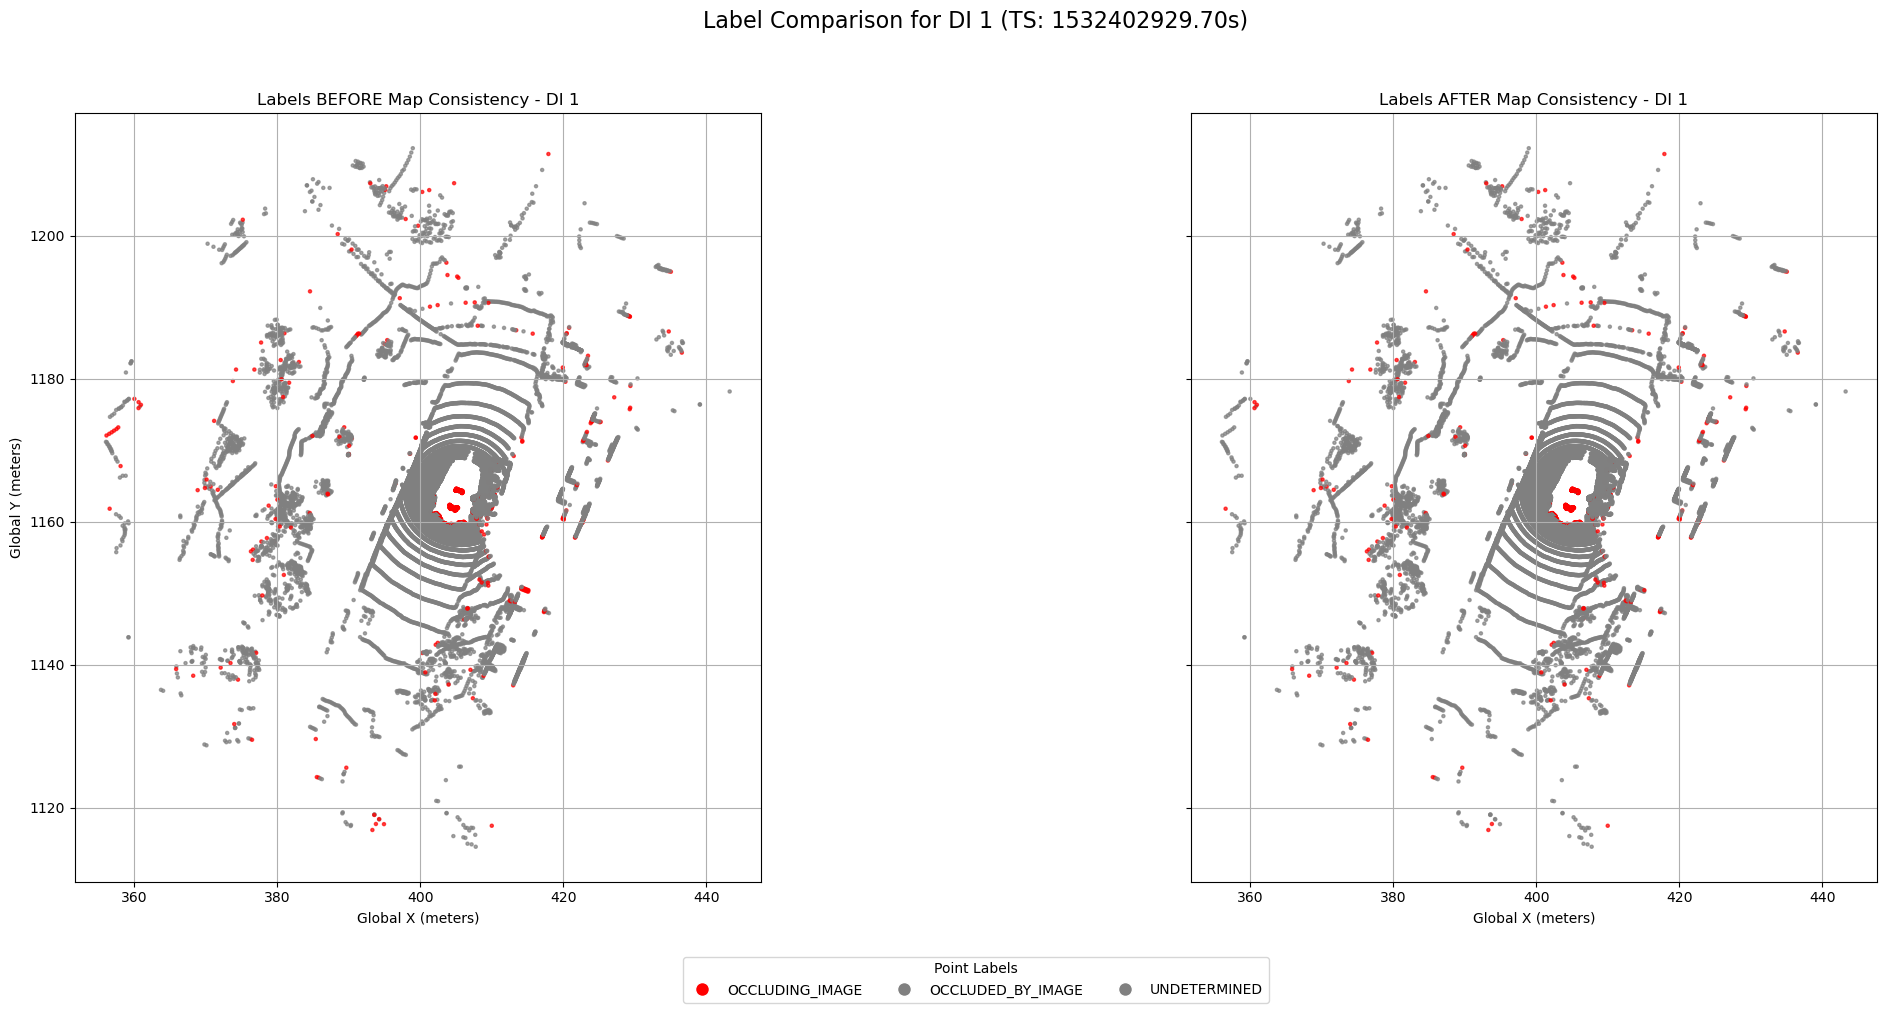

In [13]:
# Cell 14: Visualize Labeled Points from the Processed DI (Before and After MC)

if 'center_di_to_process' in locals() and center_di_to_process is not None and \
   'processing_stats' in locals() and processing_stats.get('success'):

    print(f"\n--- Visualizing Labeled Points from DI {center_index_to_process} (Timestamp: {center_di_to_process.timestamp / 1e6}s) ---")

    points_to_plot = []
    labels_before_mc_plot = []
    labels_after_mc_plot = []
    points_changed_label_count = 0

    for v_idx in range(center_di_to_process.num_pixels_v):
        for h_idx in range(center_di_to_process.num_pixels_h):
            pixel_content = center_di_to_process.get_pixel_info(v_idx, h_idx)
            if pixel_content and pixel_content['points']:
                for pt_info in pixel_content['points']:
                    points_to_plot.append(pt_info['global_pt'])
                    
                    # Get 'label_before_mc', default to UNDETERMINED if not found (shouldn't happen if code ran correctly)
                    label_before = pt_info.get('label_before_mc', OcclusionResult.UNDETERMINED)
                    # Get final 'label', default to UNDETERMINED
                    label_after = pt_info.get('label', OcclusionResult.UNDETERMINED)
                    
                    labels_before_mc_plot.append(label_before)
                    labels_after_mc_plot.append(label_after)
                    
                    if label_before != label_after and label_before == OcclusionResult.OCCLUDING_IMAGE:
                        points_changed_label_count += 1

    if not points_to_plot:
        print("No points found in the processed DI to plot.")
    else:
        points_np = np.array(points_to_plot)
        print(f"Total points plotted: {len(points_np)}")
        print(f"Points that changed label due to Map Consistency: {points_changed_label_count}")
        
        label_color_map = {
            OcclusionResult.OCCLUDING_IMAGE: 'red',      # Dynamic
            OcclusionResult.OCCLUDED_BY_IMAGE: 'gray',  # Static
            OcclusionResult.EMPTY_IN_IMAGE: 'blue',    # Ambiguous/Newly seen
            OcclusionResult.UNDETERMINED: 'gray',      # Undetermined
            "pending_classification": 'purple',        # Initial state (shouldn't be in final)
            "non_event": 'cyan',                       # Initial state (shouldn't be in final)
        }
        default_color = 'black' # For any unexpected labels

        colors_before_mc = [label_color_map.get(lbl, default_color) for lbl in labels_before_mc_plot]
        colors_after_mc = [label_color_map.get(lbl, default_color) for lbl in labels_after_mc_plot]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10), sharex=True, sharey=True)

        # Plot 1: Before Map Consistency
        ax1.scatter(points_np[:, 0], points_np[:, 1], c=colors_before_mc, s=5, alpha=0.7)
        ax1.set_xlabel("Global X (meters)")
        ax1.set_ylabel("Global Y (meters)")
        ax1.set_title(f"Labels BEFORE Map Consistency - DI {center_index_to_process}")
        ax1.set_aspect('equal', adjustable='box')
        ax1.grid(True)

        # Plot 2: After Map Consistency
        ax2.scatter(points_np[:, 0], points_np[:, 1], c=colors_after_mc, s=5, alpha=0.7)
        ax2.set_xlabel("Global X (meters)")
        # ax2.set_ylabel("Global Y (meters)") # Y-axis is shared
        ax2.set_title(f"Labels AFTER Map Consistency - DI {center_index_to_process}")
        ax2.set_aspect('equal', adjustable='box')
        ax2.grid(True)
        
        # Create common legend
        legend_handles = []
        all_unique_labels_in_plots = set(labels_before_mc_plot) | set(labels_after_mc_plot)

        # Iterate through OcclusionResult enum for ordered legend
        for label_enum_member in OcclusionResult:
            if label_enum_member in all_unique_labels_in_plots and label_enum_member in label_color_map:
                 legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                                 label=label_enum_member.name,
                                                 markerfacecolor=label_color_map[label_enum_member], markersize=10))
        
        # Add string labels if they appeared (e.g., if something went wrong or for initial states)
        for str_label_val in ["pending_classification", "non_event"]:
            if str_label_val in all_unique_labels_in_plots and str_label_val in label_color_map:
                 legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                                 label=str_label_val,
                                                 markerfacecolor=label_color_map[str_label_val], markersize=10))
        
        # Add default color to legend if it was used
        if default_color in colors_before_mc or default_color in colors_after_mc:
            if not any(h.get_label() == "Unexpected Label" for h in legend_handles):
                 legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     label="Unexpected Label",
                                     markerfacecolor=default_color, markersize=10))

        # Place legend below the subplots
        fig.legend(handles=legend_handles, title="Point Labels", loc='lower center', 
                   bbox_to_anchor=(0.5, -0.02), ncol=min(len(legend_handles), 5)) # Adjust ncol as needed
        
        fig.suptitle(f"Label Comparison for DI {center_index_to_process} (TS: {center_di_to_process.timestamp / 1e6:.2f}s)", fontsize=16)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust rect to make space for suptitle and legend
        plt.show()

else:
    print("Skipping visualization as DI was not processed successfully or data is missing.")